In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings('ignore')

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["LANGCHAIN_VERBOSE"] = "false"

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["COHERE_API_KEY"] = os.getenv("COHERE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_cohere import CohereEmbeddings
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_core.output_parsers import StrOutputParser

In [3]:
cohere_embeddings = CohereEmbeddings(model="embed-english-light-v3.0")

In [4]:
llm = ChatGroq(model="qwen/qwen3-32b")

In [5]:
import os

os.getcwd()
data_folder = os.path.join(os.getcwd(), '..', 'data')
documents = []
for filename in os.listdir(data_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(data_folder, filename)
        loader = TextLoader(file_path)
        documents.extend(loader.load())


splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=30)
split_docs = splitter.split_documents(documents)
len(split_docs)

vectorstore = FAISS.from_documents(split_docs, cohere_embeddings)
customer_it_support_db = vectorstore.save_local("customer_it_support_db")
customer_it_support_db = FAISS.load_local("customer_it_support_db",cohere_embeddings,allow_dangerous_deserialization=True)
customer_it_support_db_retriever = customer_it_support_db.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 3})

In [6]:
# Read PDF file for Film Making
from langchain_community.document_loaders import PyMuPDFLoader
file_path = "E:\Agents\data\Short-History-of-Film-Making.pdf"
loader = PyMuPDFLoader(file_path)
documents = loader.load()

film_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=60)
film_split_docs = film_splitter.split_documents(documents)
len(film_split_docs)

film_vectorstore = FAISS.from_documents(film_split_docs, cohere_embeddings)
film_vectorstore = film_vectorstore.save_local("film_db")
film_vectorstore = FAISS.load_local("film_db",cohere_embeddings,allow_dangerous_deserialization=True)
film_vectorstore_retriver_db =film_vectorstore.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 5})

In [7]:
# Read PDF file for Climate Change
from langchain_community.document_loaders import PyMuPDFLoader
claimate_path= r"E:\Agents\data\Understanding_Climate_Change.pdf"
loader = PyMuPDFLoader(claimate_path)
documents = loader.load()

claimate_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=60)
claimate_split_docs = claimate_splitter.split_documents(documents)

claimate_vectorstore = FAISS.from_documents(claimate_split_docs, cohere_embeddings)
claimate_vectorstore = claimate_vectorstore.save_local("claimate_db")

claimate_vectorstore = FAISS.load_local("claimate_db",cohere_embeddings,allow_dangerous_deserialization=True)
claimate_vectorstore_db =claimate_vectorstore.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 5})

In [8]:
# Using Tavily Search Results tool to search the web for latest information

from langchain_community.tools.tavily_search import TavilySearchResults
tavily_tool = TavilySearchResults(max_results=3)

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_10916\3186409922.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=3)


In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

# Data Model for the output of the grading agent
class GradeDocuments(BaseModel):
    """Binary score for relevance checking on retrieved documents"""
    binary_score:str =Field(description="Document relevance score as binary: 'yes' or 'no'")

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

#Prompt
System ="""your are grader assisting a RAG agent to determine whether the retrieved documents are relevant to the user query.
You will be given a user query and the retrieved documents for that query."""

grader_prompt = ChatPromptTemplate.from_messages([
    ("system", System),
    ("human", "User Query: {query} \n Retrieved Documents: {retrieved_docs} \n Are the retrieved documents relevant to the user query? Answer with 'yes' or 'no'.")
])

retrieval_grader = grader_prompt | structured_llm_grader
query="film making techniques in 1920s?"
retrieved_docs = film_vectorstore_retriver_db.invoke(query)
print(retrieval_grader.invoke({"query": query, "retrieved_docs": retrieved_docs}))

binary_score='yes'


In [11]:
# Generate
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-120b",temperature=0)

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": retrieved_docs, "question": question})
    return {"messages": [response]}

In [12]:
# Question Rewriting


llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0)

System = """You are a helpful assistant for rewriting user queries to be more specific for better retrieval results.
You will be given a user query and the retrieved documents for that query."""
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", System), 
    ("human", "User Query: {query} \n Retrieved Documents: {retrieved_docs} \n Rewrite the user query to be more specific for better retrieval results.")])

question_rewrite_chain = rewrite_prompt | llm | StrOutputParser()
question_rewrite_chain.invoke({"query": query, "retrieved_docs": retrieved_docs})
question_rewrite_chain.invoke({"query":"what are the film making techniques used in 1920s?", "retrieved_docs": retrieved_docs})

'To get more specific and relevant results, the user query can be rewritten as:\n\n"What were the key cinematographic techniques, such as camera movements, editing, and lighting, used in filmmaking during the 1920s, and how did they contribute to the development of the medium?"\n\nThis rewritten query is more specific because it:\n\n1. Specifies the time period (1920s) to focus on a particular era in filmmaking.\n2. Asks about specific cinematographic techniques (camera movements, editing, lighting) to get more detailed information.\n3. Inquires about the contribution of these techniques to the development of filmmaking, which can provide a deeper understanding of the subject.\n\nAlternatively, the query could be broken down into more specific sub-questions, such as:\n\n* What were the most influential camera techniques used in 1920s filmmaking?\n* How did editing evolve during the 1920s, and what were some notable editing techniques used during this period?\n* What role did lighting p

In [13]:
from typing import List
from typing_extensions import TypedDict
from langchain_classic import hub

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

# Define RAG chain for generation
rag_prompt = hub.pull("rlm/rag-prompt")
rag_chain = rag_prompt | llm | StrOutputParser()


In [ ]:
def retrieve(state):
    """
    Retrieve documents
    
    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]
    
    # Retrieval
    documents = claimate_vectorstore_db.invoke(question)
    return {"documents": documents, "question": question, "web_search": "No"}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question
    If any documents are not relevant, we set a flag to run web search
    
    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): Filtered out irrelevant documents and a flag, web_search
    """
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    
    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"query": question, "retrieved_docs": d.page_content}
        )
        grade = score.binary_score
        # Document relevant
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        # Document not relevant
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            # We do not include the document in filtered_docs
            # Flag for web search
            web_search = "Yes"
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewrite_chain.invoke({"query": question, "retrieved_docs": str(documents)})
    return {"documents": documents, "question": better_question, "web_search": "No"}


def web_search_node(state):
    """
    Web search based on the question
    
    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): Appends web results to documents
    """
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]
    
    # Web search - tavily_tool returns list of dicts with 'content' and 'url' keys
    docs = tavily_tool.invoke({"query": question})
    web_results = "\n".join([d.get("content", "") for d in docs])
    web_results = Document(page_content=web_results)
    if documents is not None and len(documents) > 0:
        documents.append(web_results)
    else:
        documents = [web_results]
    return {"documents": documents, "question": question, "web_search": "No"}


def generate(state):
    """
    Generate answer
    
    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    
    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [18]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search_node)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a new question.
    
    Args:
        state (dict): The current graph state
    
    Returns:
        str: Next node to call
    """
    web_search = state["web_search"]
    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        return "generate"

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

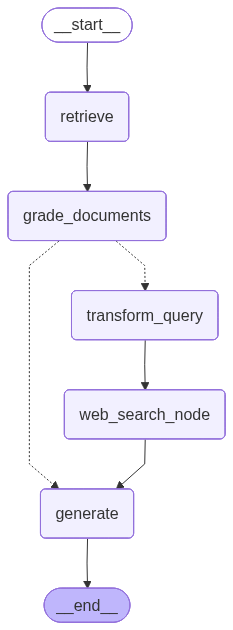

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [20]:
app.invoke({"question":"what is drought?", "documents": []})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---TRANSFORM QUERY---
---WEB SEARCH---


TypeError: string indices must be integers, not 'str'